VAE Code (MNIST)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparams
batch_size = 128
latent_dim = 2  # 2D for visualization

# Data
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True)

# VAE Model
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Loss
def loss_fn(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Train
for epoch in range(5):
    model.train()
    total_loss = 0
    for data, _ in train_loader:
        data = data.view(-1, 784).to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = loss_fn(recon, data, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}, Loss: {total_loss:.2f}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.81MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 167kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.73MB/s]


Epoch 0, Loss: 11419316.98
Epoch 1, Loss: 10105276.21
Epoch 2, Loss: 9886562.63
Epoch 3, Loss: 9745034.14
Epoch 4, Loss: 9642122.21


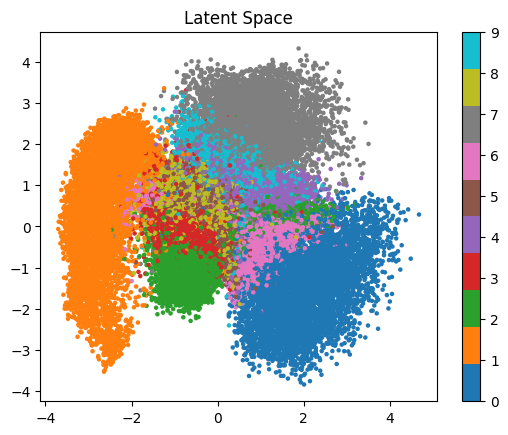

In [ ]:
model.eval()
z_points = []
labels = []

with torch.no_grad():
    for data, label in train_loader:
        data = data.view(-1, 784).to(device)
        mu, _ = model.encode(data)
        z_points.append(mu.cpu())
        labels.append(label)

z = torch.cat(z_points)
labels = torch.cat(labels)

plt.scatter(z[:, 0], z[:, 1], c=labels, cmap='tab10', s=5)
plt.colorbar()
plt.title("Latent Space")
plt.show()

GAN for Image Synthesis (MNIST)

In [ ]:
import torch.nn as nn

latent_dim = 100

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=2e-4)
opt_D = optim.Adam(D.parameters(), lr=2e-4)

# Training
for epoch in range(5):
    for real, _ in train_loader:
        real = real.view(-1, 784).to(device)

        # Train Discriminator
        z = torch.randn(real.size(0), latent_dim).to(device)
        fake = G(z)

        loss_D = criterion(D(real), torch.ones_like(D(real))) + \
                 criterion(D(fake.detach()), torch.zeros_like(D(fake)))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        loss_G = criterion(D(fake), torch.ones_like(D(fake)))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Epoch 0 | D Loss: 0.3274 | G Loss: 4.4622
Epoch 1 | D Loss: 2.0728 | G Loss: 2.0704
Epoch 2 | D Loss: 0.5423 | G Loss: 1.7914
Epoch 3 | D Loss: 0.4136 | G Loss: 4.6380
Epoch 4 | D Loss: 0.0999 | G Loss: 4.8189


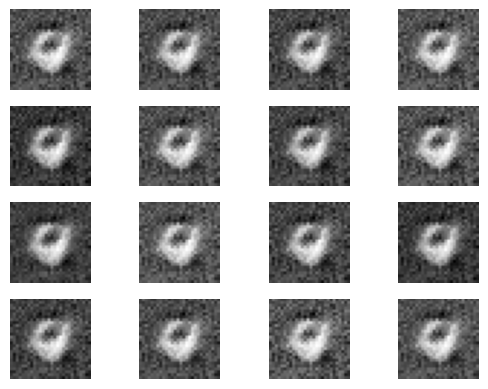

In [ ]:
z = torch.randn(16, latent_dim).to(device)
samples = G(z).view(-1, 28, 28).detach().cpu()

fig, axs = plt.subplots(4, 4)
for i in range(16):
    axs[i//4, i%4].imshow(samples[i], cmap='gray')
    axs[i//4, i%4].axis('off')
plt.show()

Graph Convolutional Network (GCN) on Citation Data (Cora)

In [ ]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 813.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.9 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

dataset = Planetoid(root='./data', name='Cora')
data = dataset[0].to(device)

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = GCN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

# Test
model.eval()
pred = model(data).argmax(dim=1)
correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())
print("Accuracy:", acc)

Processing...
Done!


Accuracy: 0.782
